In [25]:
# Sigar

In [26]:
import os

pwd = os.getcwd()
if pwd.endswith("notebooks"):
    os.chdir("..")

In [27]:
from scm import SCM
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [28]:
np.random.seed(42)
s = SCM()

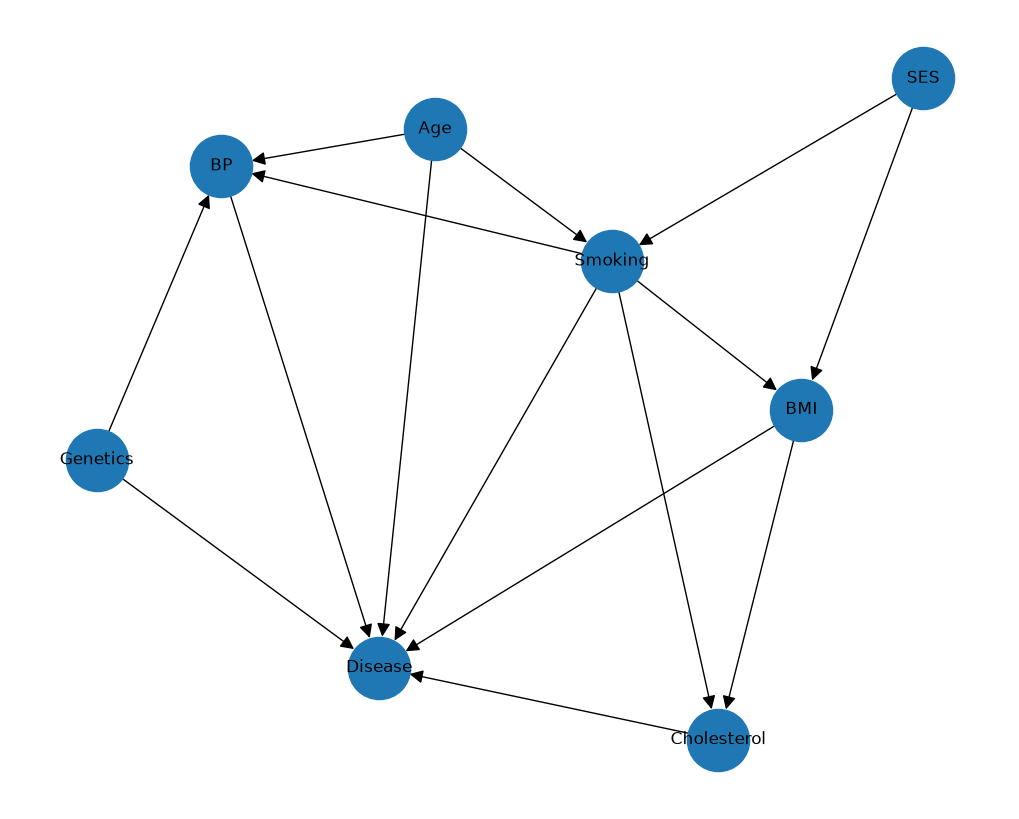

In [29]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def eq_age(_, n):
    return np.random.normal(50, 10, n)

def eq_SES(_, n):
    return np.random.normal(0, 1, n)

def eq_genetics(_, n):
    return np.random.normal(0, 1, n)

def eq_smoking(parents, n):
    age = parents['Age']
    ses = parents['SES']
    
    prob = sigmoid(-2 + 0.03 * age - 0.5 * ses)
    
    epsilon = np.random.uniform(0, 1, n)
    
    return (epsilon < prob).astype(int)

def eq_BMI(parents, n):
    smoking = parents['Smoking']
    ses = parents['SES']
    epsilon = np.random.normal(0, 3, n)
    
    return 25 + 2 * smoking - ses + epsilon

def eq_BP(parents, n):
    smoking = parents['Smoking']
    age = parents['Age']
    genetics = parents['Genetics']
    epsilon = np.random.normal(0, 10, n)
    
    return 120 + 5 * smoking + 0.3 * age + 2 * genetics + epsilon

def eq_cholesterol(parents, n):
    smoking = parents['Smoking']
    BMI = parents['BMI']
    epsilon = np.random.normal(0, 15, n)
    
    return 180 + 10 * smoking - 0.5 * BMI + epsilon

def eq_disease(parents, n):
    smoking = parents['Smoking']
    age = parents['Age']
    BMI = parents['BMI']
    BP = parents['BP']
    cholesterol = parents['Cholesterol']
    genetics = parents['Genetics']
    
    linear = (-15 + 0.6 * smoking + 0.02 * age + 0.01 * BMI + 
              0.03 * BP + 0.04 * cholesterol + 0.2 * genetics)
    
    prob = sigmoid(linear)
    
    return prob


s.add_variable('Age', [], eq_age)
s.add_variable('SES', [], eq_SES)
s.add_variable('Genetics', [], eq_genetics)

s.add_variable('Smoking', ['Age', 'SES'], eq_smoking)

s.add_variable('BMI', ['Smoking', 'SES'], eq_BMI)
s.add_variable('BP', ['Smoking', 'Age', 'Genetics'], eq_BP)

s.add_variable('Cholesterol', ['Smoking', 'BMI'], eq_cholesterol)

s.add_variable('Disease', ['Smoking', 'Age', 'BMI', 'BP', 'Cholesterol', 'Genetics'], eq_disease)

s.plot_graph("SCM: Health and Disease Model")
plt.savefig("../report/images/cig_causal_graph.png", dpi=300)


In [30]:
interv_scm = s.do_operator({"Smoking": 1})
interv_samples = interv_scm.sample(10_000)
e1 = interv_samples["Disease"].mean()
interv_scm = s.do_operator({"Smoking": 0})
interv_samples = interv_scm.sample(10_000)
e0 = interv_samples["Disease"].mean()
print("ATE",e1 - e0)

ATE 0.09618307044069563


In [31]:
samples = s.sample(10_000)
samples = samples[samples["Smoking"] == 1]

e1 = samples["Disease"].mean()
samples["Smoking"] = 0
samples["Disease"] = eq_disease(samples, len(samples))
e0 = samples["Disease"].mean()
print("ATT", e1 - e0)

ATT 0.06294287833251536


In [32]:
samples = s.sample(10_000)
samples1 = samples[samples["Age"] > 55]
samples2 = samples[samples["Age"] <= 55]
for samples in (samples1, samples2):
    samples["Smoking"] = 1
    samples["Disease"] = eq_disease(samples, len(samples))
    e1 = samples["Disease"].mean()
    samples["Smoking"] = 0
    samples["Disease"] = eq_disease(samples, len(samples))
    e0 = samples["Disease"].mean()
    print("CATE", e1 - e0)

CATE 0.06257998919727491
CATE 0.042922818228705154
